In [2]:
# Cell 1: Load Data and Apply Timestamp Offsets

import pandas as pd
import os

# Define the base path to the data directory relative to the notebook location
data_path = os.path.join('..', 'data')

# Define file names
price_files = {
    2: os.path.join(data_path, 'prices_round_5_day_2.csv'),
    3: os.path.join(data_path, 'prices_round_5_day_3.csv'),
    4: os.path.join(data_path, 'prices_round_5_day_4.csv')
}

trade_files = {
    2: os.path.join(data_path, 'trades_round_5_day_2.csv'),
    3: os.path.join(data_path, 'trades_round_5_day_3.csv'),
    4: os.path.join(data_path, 'trades_round_5_day_4.csv')
}

# Define timestamp offsets (Day 3: +1M, Day 4: +2M)
timestamp_offsets = {
    2: 0,
    3: 1_000_000,
    4: 2_000_000
}

# --- Load and Process Price Data ---
all_prices_list = []
for day, file_path in price_files.items():
    try:
        prices_day_df = pd.read_csv(file_path, sep=';')
        offset = timestamp_offsets[day]
        if offset > 0:
            prices_day_df['timestamp'] += offset
        all_prices_list.append(prices_day_df)
    except FileNotFoundError:
        print(f"Warning: Price file not found at {file_path}")
    except Exception as e:
        print(f"Warning: Error loading price file {file_path}: {e}")

# Concatenate all price data
if all_prices_list:
    df_prices = pd.concat(all_prices_list, ignore_index=True)
else:
    df_prices = pd.DataFrame() # Create empty df if loading failed


# --- Load and Process Trade Data ---
all_trades_list = []
for day, file_path in trade_files.items():
    try:
        trades_day_df = pd.read_csv(file_path, sep=';')
        offset = timestamp_offsets[day]
        if offset > 0:
            trades_day_df['timestamp'] += offset
        all_trades_list.append(trades_day_df)
    except FileNotFoundError:
        print(f"Warning: Trade file not found at {file_path}")
    except Exception as e:
        print(f"Warning: Error loading trade file {file_path}: {e}")

# Concatenate all trade data
if all_trades_list:
    df_trades = pd.concat(all_trades_list, ignore_index=True)
else:
    df_trades = pd.DataFrame() # Create empty df if loading failed



print("Trades Data Head (df_trades):")
if not df_trades.empty:
    print(df_trades.head())
else:
    print("Trade data is empty.")

# ***** ADD THESE LINES AT THE END OF CELL 1 *****
print("\nColumns in df_prices after loading:")
print(df_prices.columns)
print("\nHead of df_prices after loading:")
print(df_prices.head())
# ***** END OF ADDED LINES *****

Trades Data Head (df_trades):
   timestamp    buyer   seller            symbol   currency   price  quantity
0          0   Caesar    Paris        CROISSANTS  SEASHELLS  4265.0         8
1        100  Charlie    Paris  RAINFOREST_RESIN  SEASHELLS  9999.0         1
2        200    Paris   Caesar        CROISSANTS  SEASHELLS  4266.0         8
3        200    Paris   Caesar              JAMS  SEASHELLS  6520.0         7
4        200    Paris  Charlie              KELP  SEASHELLS  2046.0         1

Columns in df_prices after loading:
Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

Head of df_prices after loading:
   day  timestamp                     product  bid_price_1  bid_volume_1  \
0    2          0              PICNIC_BASKET2      3009

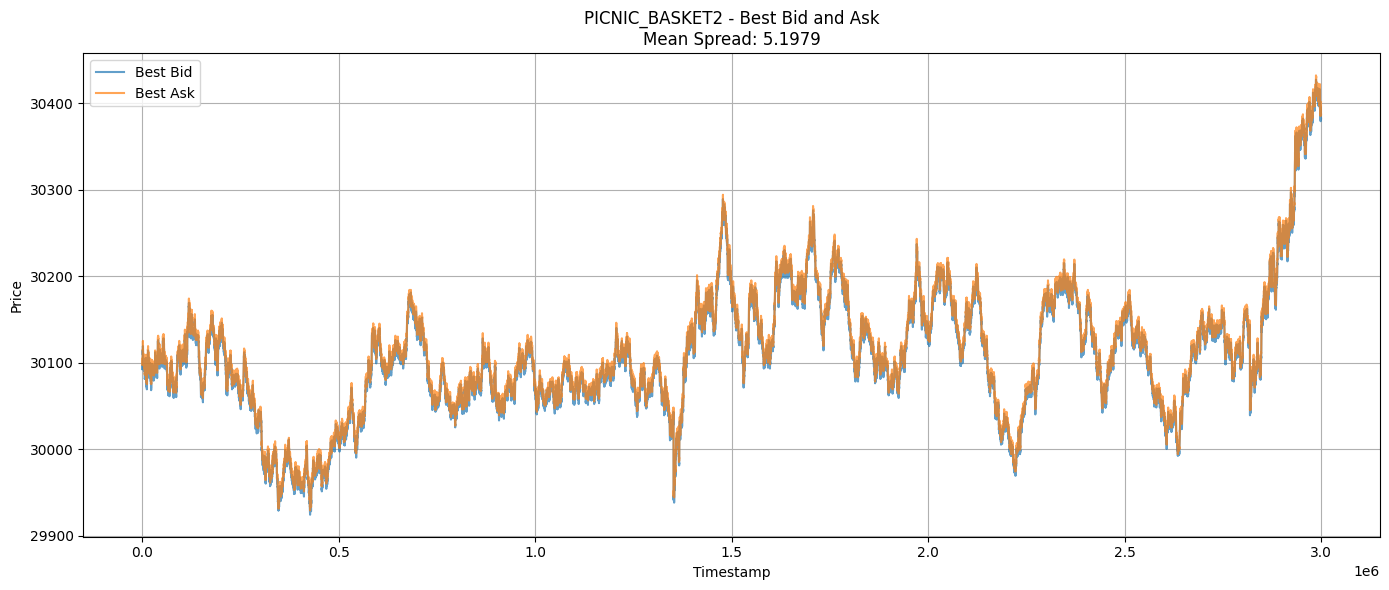

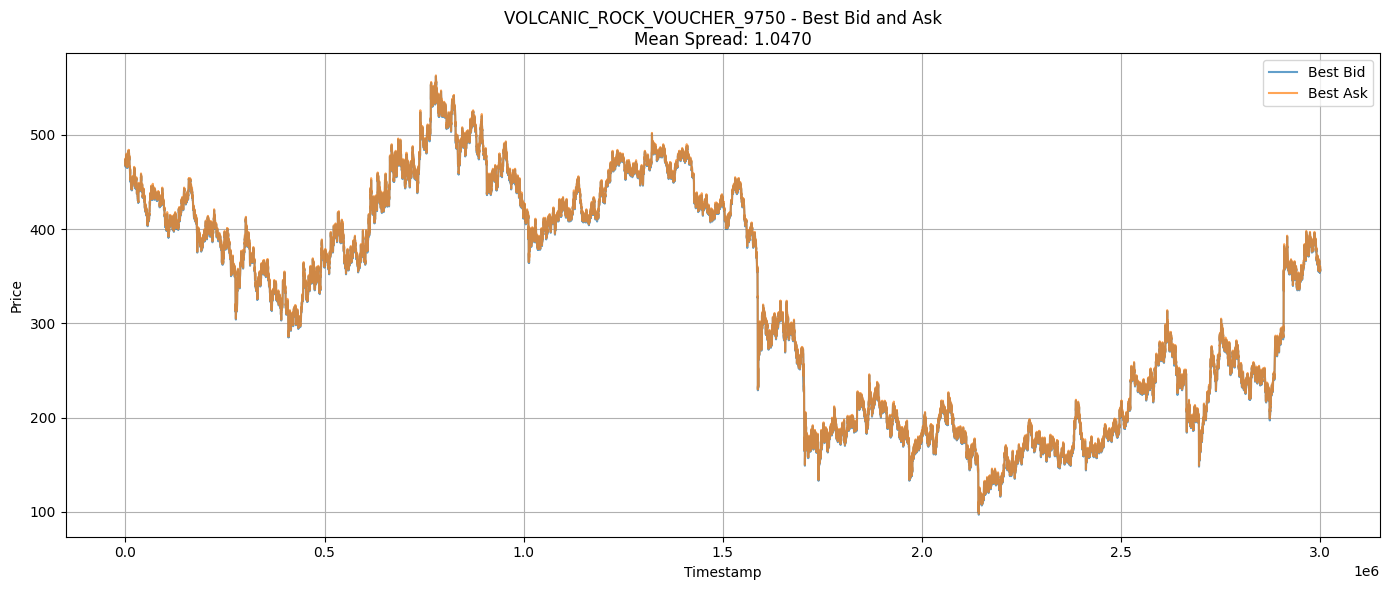

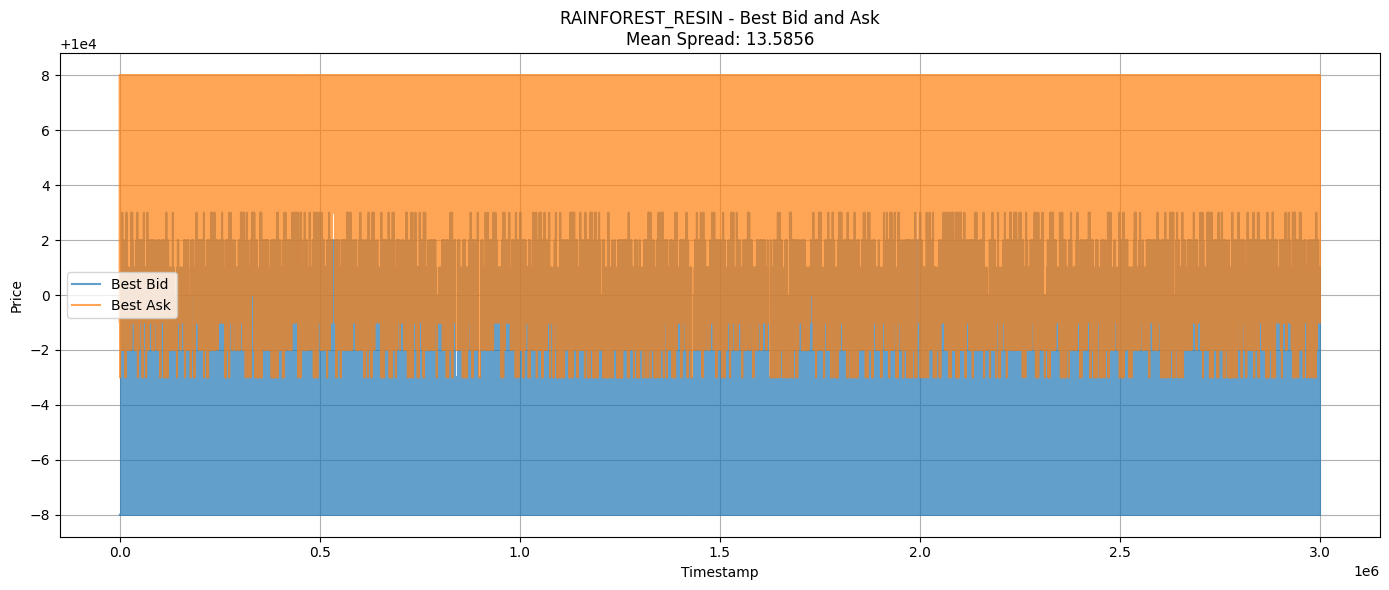

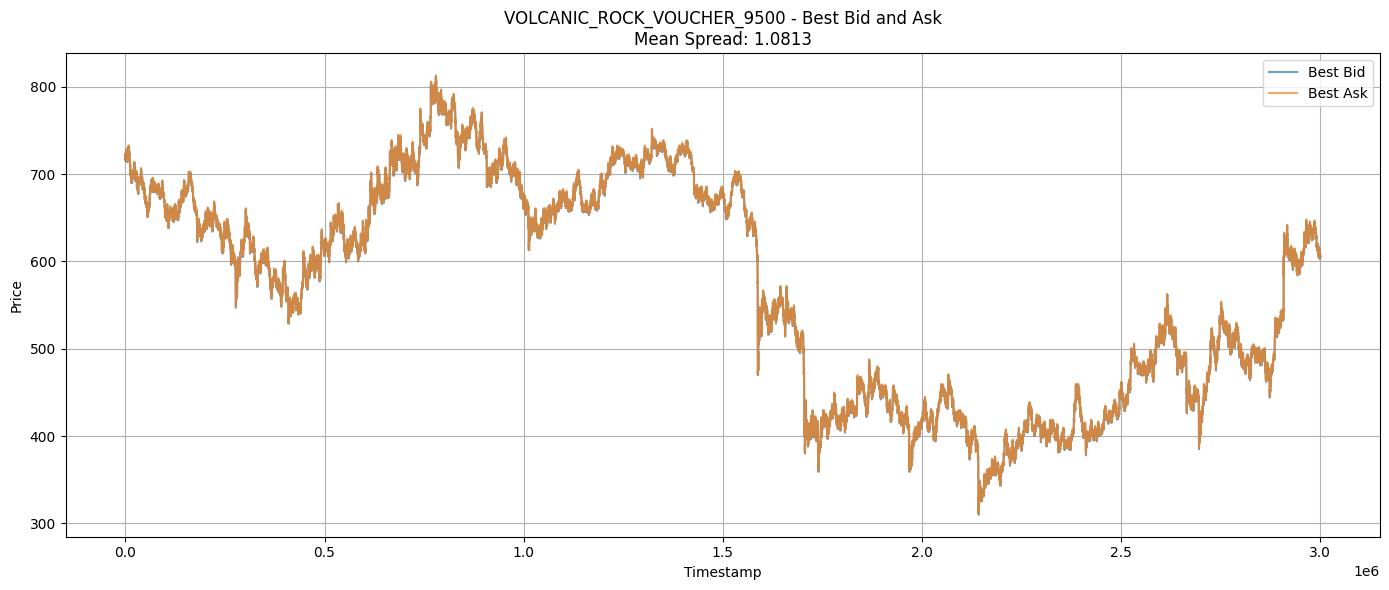

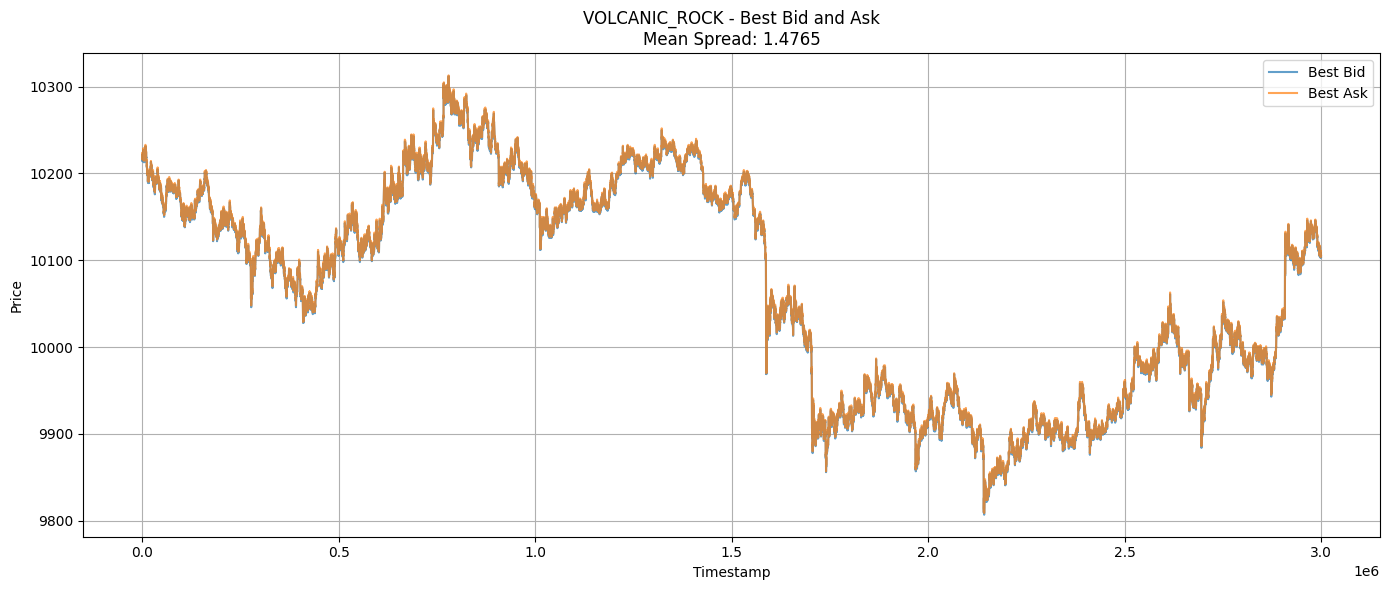

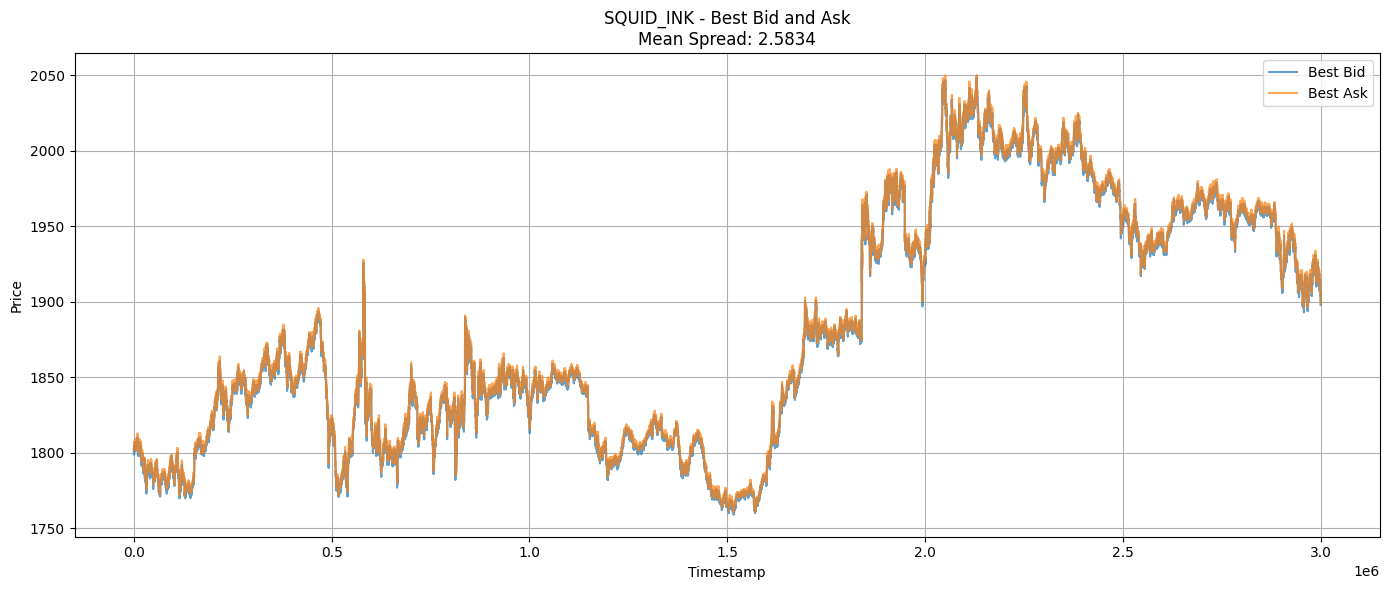

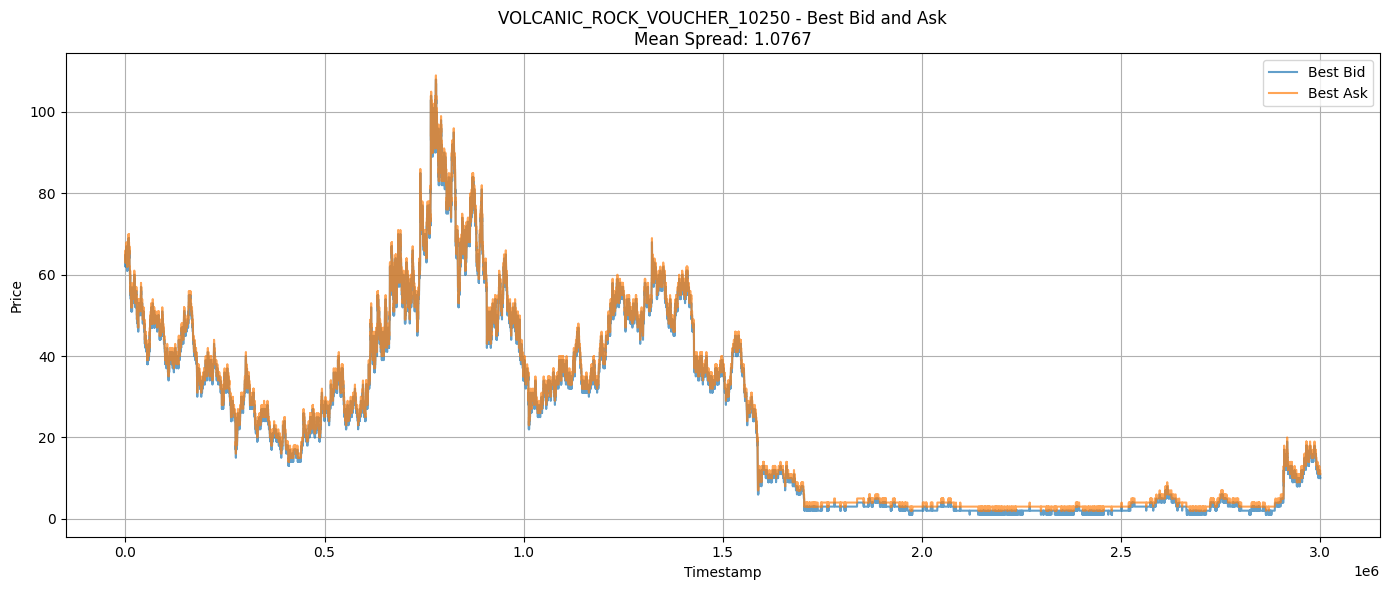

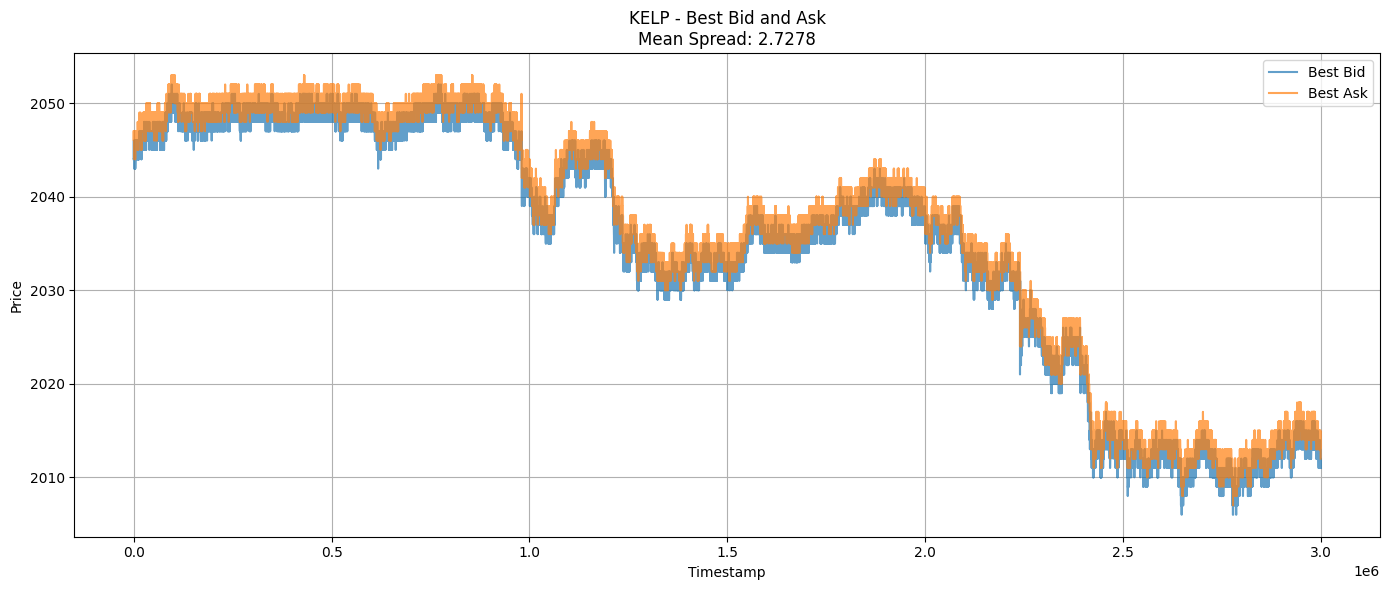

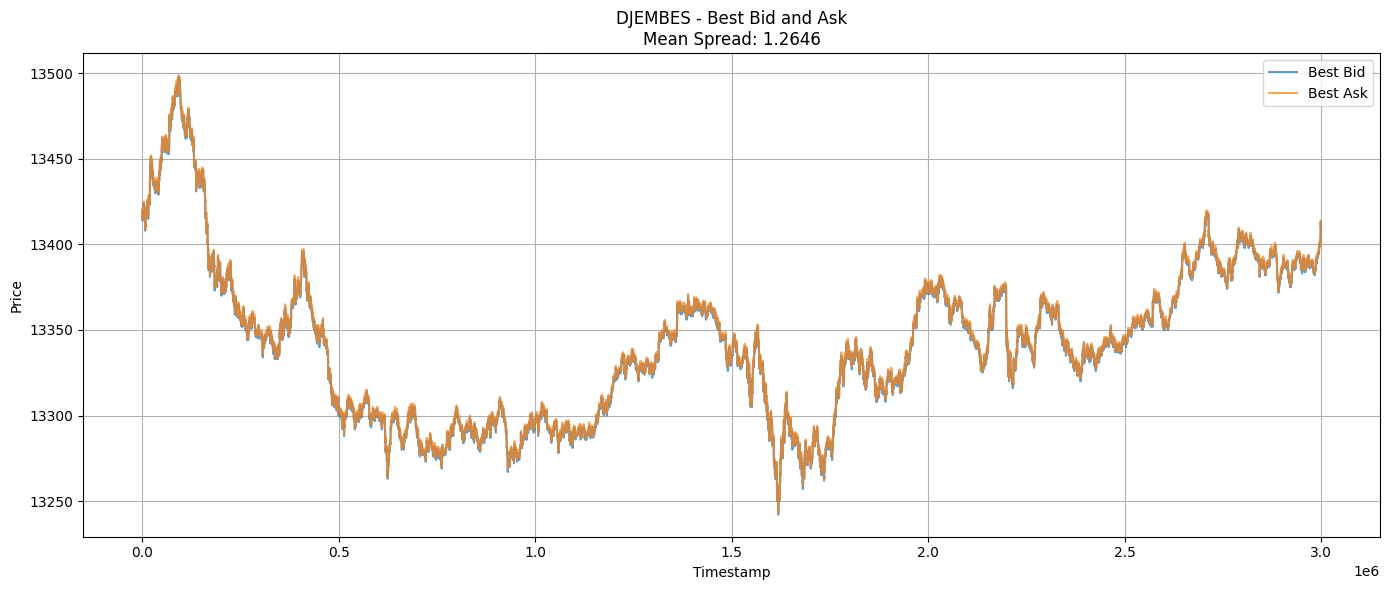

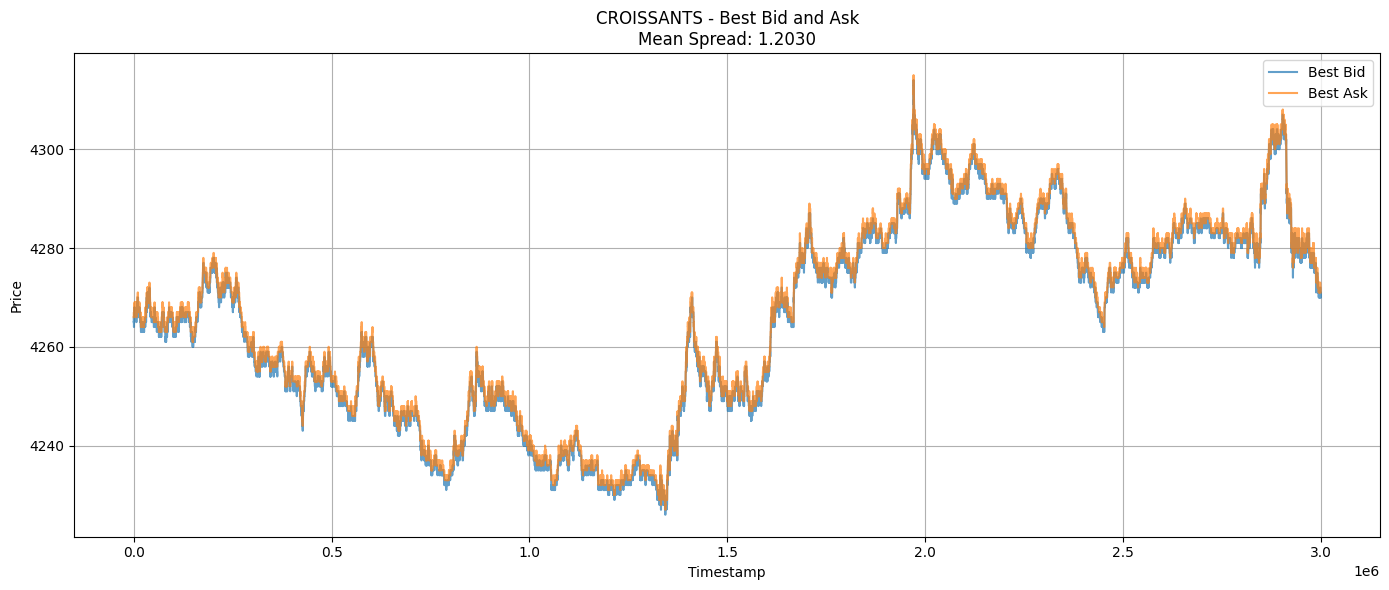

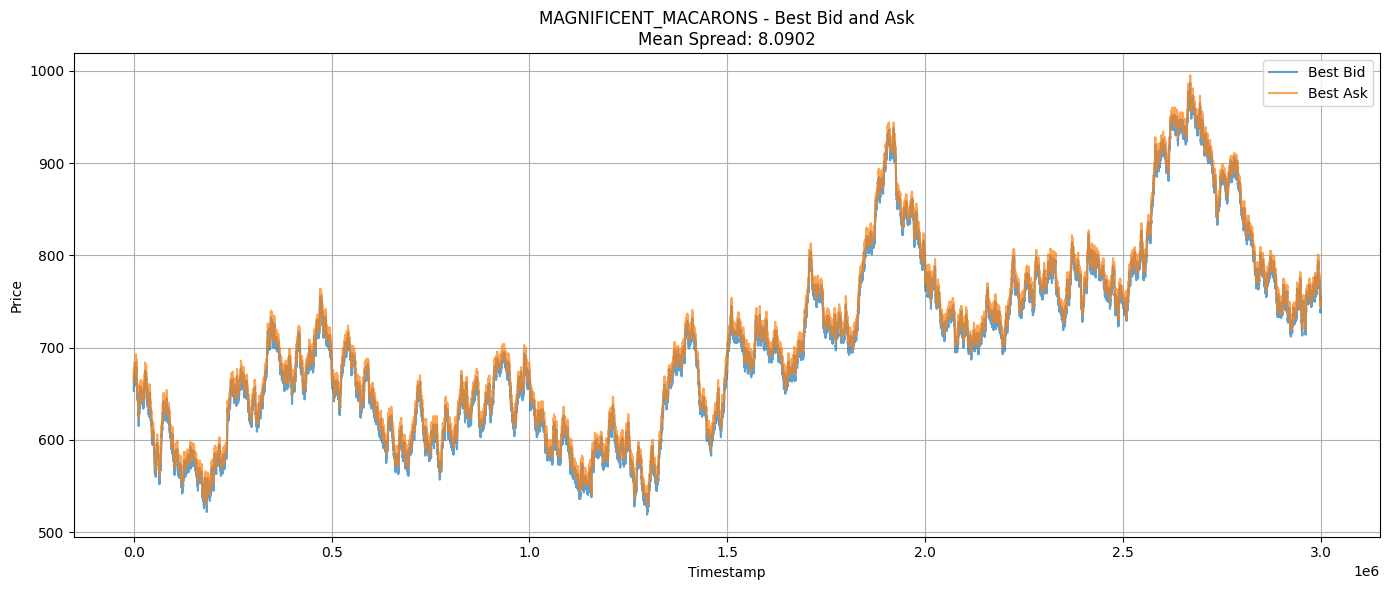

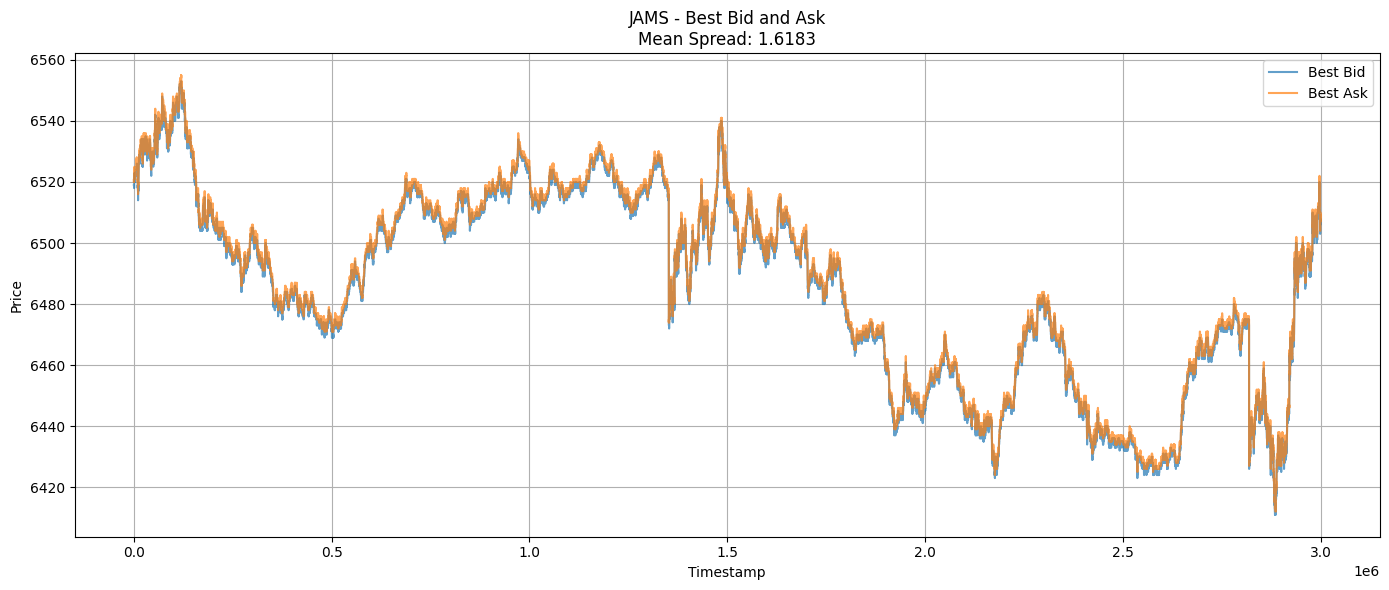

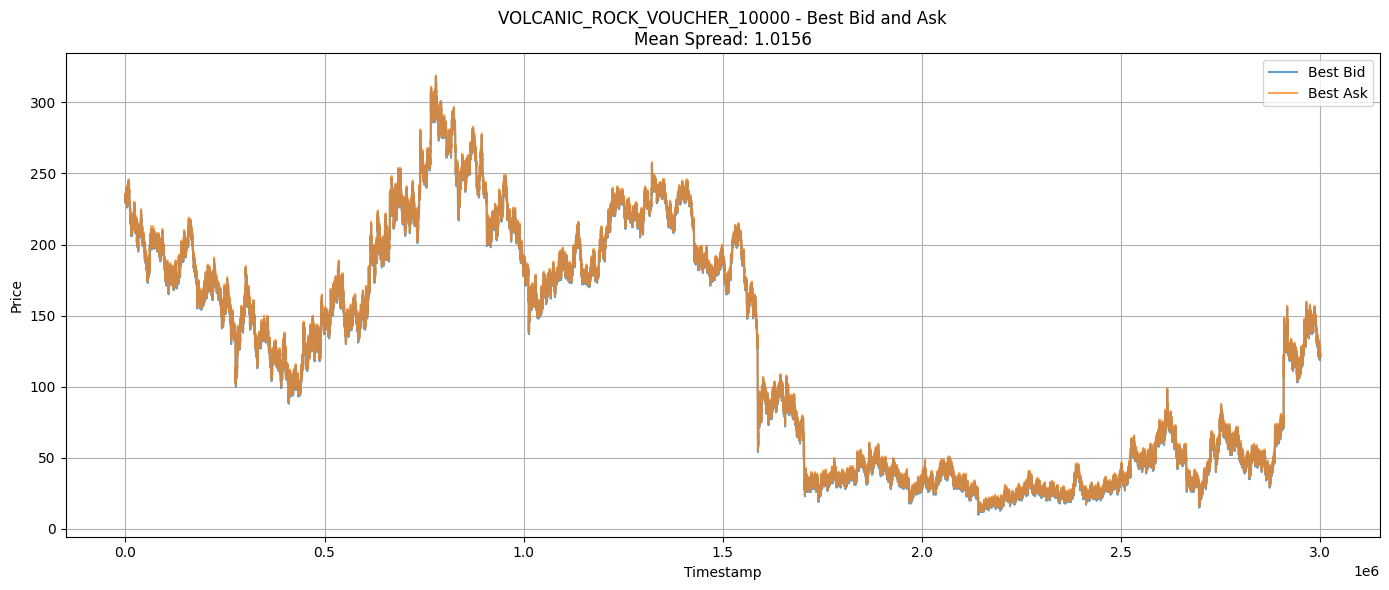

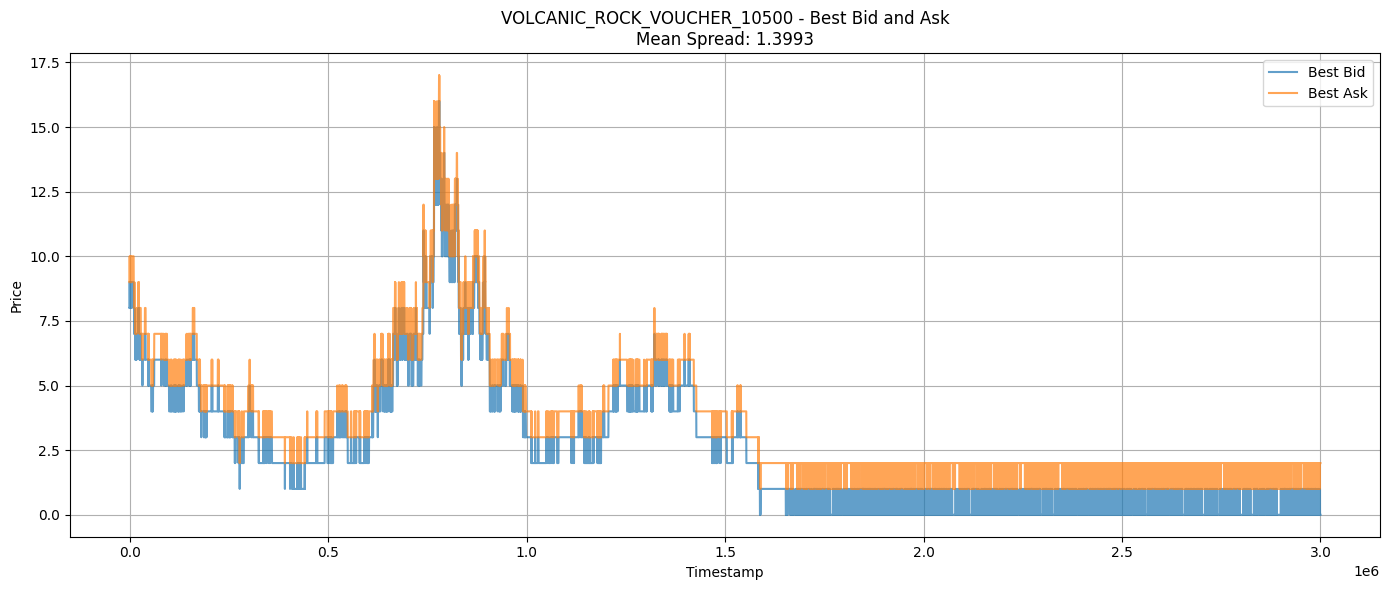

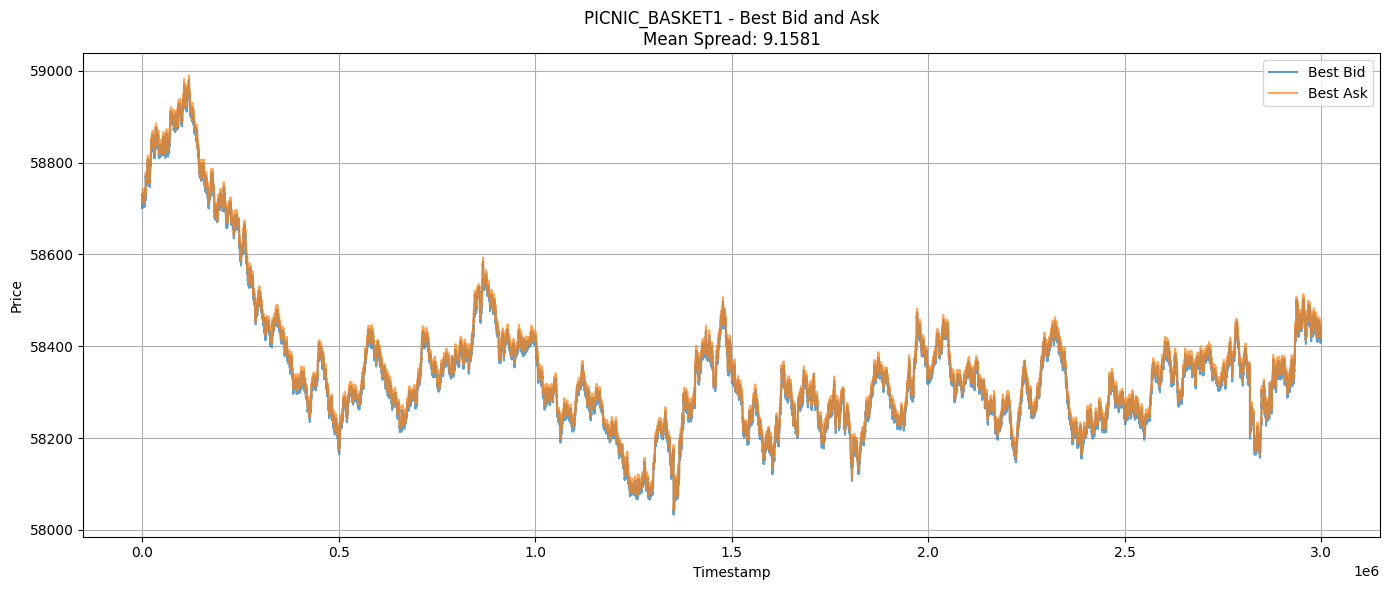

In [3]:
import matplotlib.pyplot as plt

# Ensure correct dtypes
df_prices["timestamp"] = pd.to_numeric(df_prices["timestamp"], errors='coerce')
df_prices["bid_price_1"] = pd.to_numeric(df_prices["bid_price_1"], errors='coerce')
df_prices["ask_price_1"] = pd.to_numeric(df_prices["ask_price_1"], errors='coerce')

# Drop rows with missing price data
df_prices.dropna(subset=["timestamp", "bid_price_1", "ask_price_1"], inplace=True)

# Get all unique products in the data
products = df_prices["product"].unique()

# Plot for each product
for product in products:
    df_product = df_prices[df_prices["product"] == product].copy()
    df_product.sort_values("timestamp", inplace=True)
    mean_spread = (df_product["ask_price_1"] - df_product["bid_price_1"]).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(df_product["timestamp"], df_product["bid_price_1"], label="Best Bid", alpha=0.7)
    plt.plot(df_product["timestamp"], df_product["ask_price_1"], label="Best Ask", alpha=0.7)
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.title(f"{product} - Best Bid and Ask\nMean Spread: {mean_spread:.4f}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


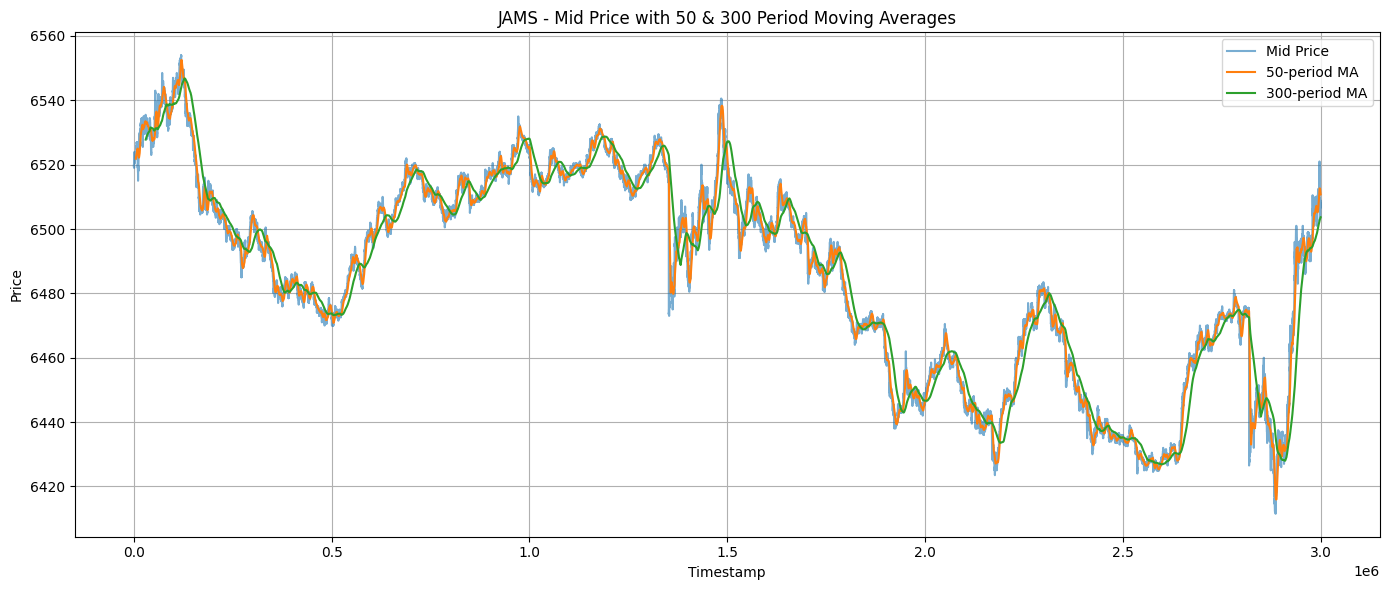

In [4]:
import matplotlib.pyplot as plt

# Filter JAMS and sort
df_jams = df_prices[df_prices["product"] == "JAMS"].copy()
df_jams.sort_values("timestamp", inplace=True)

# Calculate mid price
df_jams["mid_price"] = (df_jams["bid_price_1"] + df_jams["ask_price_1"]) / 2

# Compute moving averages
df_jams["MA_50"] = df_jams["mid_price"].rolling(window=50).mean()
df_jams["MA_300"] = df_jams["mid_price"].rolling(window=300).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_jams["timestamp"], df_jams["mid_price"], label="Mid Price", alpha=0.6)
plt.plot(df_jams["timestamp"], df_jams["MA_50"], label="50-period MA", linewidth=1.5)
plt.plot(df_jams["timestamp"], df_jams["MA_300"], label="300-period MA", linewidth=1.5)
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.title("JAMS - Mid Price with 50 & 300 Period Moving Averages")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
import plotly.graph_objects as go
import numpy as np

# --- 1. Filter and Prepare Data ---
df_squid = df_prices[df_prices["product"] == "CROISSANTS"].copy()
df_squid.sort_values("timestamp", inplace=True)
df_squid["mid_price"] = (df_squid["bid_price_1"] + df_squid["ask_price_1"]) / 2
df_squid["MA_300"] = df_squid["mid_price"].rolling(window=300).mean()
df_squid["MA_slope"] = df_squid["MA_300"].diff()

# Filter Olivia trades
olivia_trades = df_trades[
    (df_trades["symbol"] == "CROISSANTS") &
    ((df_trades["buyer"] == "Olivia") | (df_trades["seller"] == "Olivia"))
].copy()
olivia_trades["signed_qty"] = olivia_trades.apply(
    lambda row: row["quantity"] if row["buyer"] == "Olivia" else -row["quantity"], axis=1
)

# --- 2. Build Plot ---
fig = go.Figure()

# Bid / Ask
fig.add_trace(go.Scatter(
    x=df_squid["timestamp"], y=df_squid["bid_price_1"],
    mode="lines", name="Best Bid", line=dict(color="blue"), opacity=0.5
))
fig.add_trace(go.Scatter(
    x=df_squid["timestamp"], y=df_squid["ask_price_1"],
    mode="lines", name="Best Ask", line=dict(color="red"), opacity=0.5
))

# 300-period MA with slope info in hover
fig.add_trace(go.Scatter(
    x=df_squid["timestamp"],
    y=df_squid["MA_300"],
    mode="lines",
    name="300 MA",
    line=dict(color="orange", width=2),
    customdata=np.stack([df_squid["MA_slope"]], axis=-1),
    hovertemplate="Timestamp: %{x}<br>300 MA: %{y:.2f}<br>MA Slope: %{customdata[0]:.4f}<extra></extra>"
))

# Olivia Buys
buys = olivia_trades[olivia_trades["signed_qty"] > 0]
fig.add_trace(go.Scatter(
    x=buys["timestamp"], y=buys["price"],
    mode="markers", name="Olivia Buys",
    marker=dict(color="green", size=6, symbol="circle"),
    hovertemplate="Timestamp: %{x}<br>Buy @ %{y}<extra></extra>"
))

# Olivia Sells
sells = olivia_trades[olivia_trades["signed_qty"] < 0]
fig.add_trace(go.Scatter(
    x=sells["timestamp"], y=sells["price"],
    mode="markers", name="Olivia Sells",
    marker=dict(color="red", size=6, symbol="x"),
    hovertemplate="Timestamp: %{x}<br>Sell @ %{y}<extra></extra>"
))

# --- Layout ---
fig.update_layout(
    title="CROISSANTS – Bid/Ask, 300 MA, and Olivia's Trades",
    xaxis_title="Timestamp",
    yaxis_title="Price",
    template="plotly_dark",
    hovermode="x unified",
    height=600,
    legend=dict(bgcolor="rgba(0,0,0,0)")
)

fig.show()


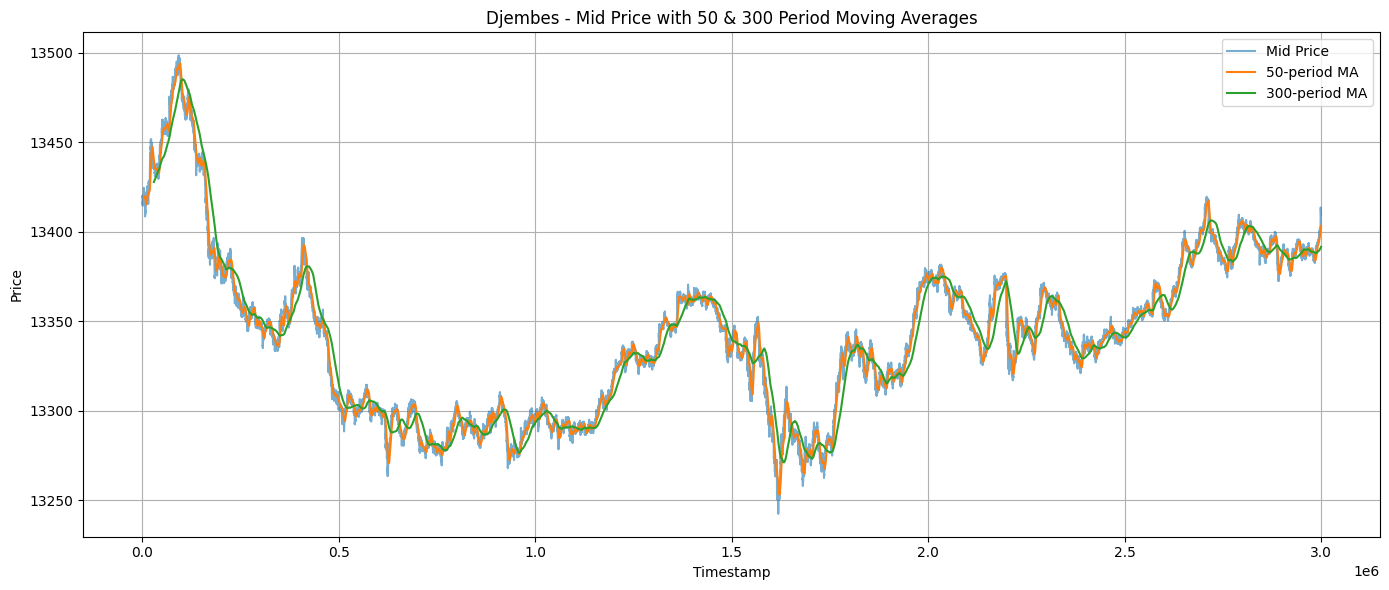

In [6]:
import matplotlib.pyplot as plt

# Filter JAMS and sort
df_djembes  = df_prices[df_prices["product"] == "DJEMBES"].copy()
df_djembes.sort_values("timestamp", inplace=True)

# Calculate mid price
df_djembes["mid_price"] = (df_djembes["bid_price_1"] + df_djembes["ask_price_1"]) / 2

# Compute moving averages
df_djembes["MA_50"] = df_djembes["mid_price"].rolling(window=50).mean()
df_djembes["MA_300"] = df_djembes["mid_price"].rolling(window=300).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_djembes["timestamp"], df_djembes["mid_price"], label="Mid Price", alpha=0.6)
plt.plot(df_djembes["timestamp"], df_djembes["MA_50"], label="50-period MA", linewidth=1.5)
plt.plot(df_djembes["timestamp"], df_djembes["MA_300"], label="300-period MA", linewidth=1.5)
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.title("Djembes - Mid Price with 50 & 300 Period Moving Averages")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import plotly.graph_objects as go

# --- Prepare data ---
df_djembes = df_prices[df_prices["product"] == "DJEMBES"].copy()
df_djembes.sort_values("timestamp", inplace=True)

df_djembes["mid_price"] = (df_djembes["bid_price_1"] + df_djembes["ask_price_1"]) / 2
df_djembes["MA_50"] = df_djembes["mid_price"].rolling(window=50).mean()
df_djembes["MA_300"] = df_djembes["mid_price"].rolling(window=300).mean()

# --- Create plot ---
fig = go.Figure()

# Mid Price
fig.add_trace(go.Scatter(
    x=df_djembes["timestamp"],
    y=df_djembes["mid_price"],
    mode="lines",
    name="Mid Price",
    line=dict(color="white", width=1),
    opacity=0.6,
    hovertemplate="Timestamp: %{x}<br>Mid: %{y:.2f}<extra></extra>"
))

# 50-period MA
fig.add_trace(go.Scatter(
    x=df_djembes["timestamp"],
    y=df_djembes["MA_50"],
    mode="lines",
    name="50-period MA",
    line=dict(color="cyan", width=2),
    hovertemplate="Timestamp: %{x}<br>MA_50: %{y:.2f}<extra></extra>"
))

# 300-period MA
fig.add_trace(go.Scatter(
    x=df_djembes["timestamp"],
    y=df_djembes["MA_300"],
    mode="lines",
    name="300-period MA",
    line=dict(color="orange", width=2),
    hovertemplate="Timestamp: %{x}<br>MA_300: %{y:.2f}<extra></extra>"
))

#


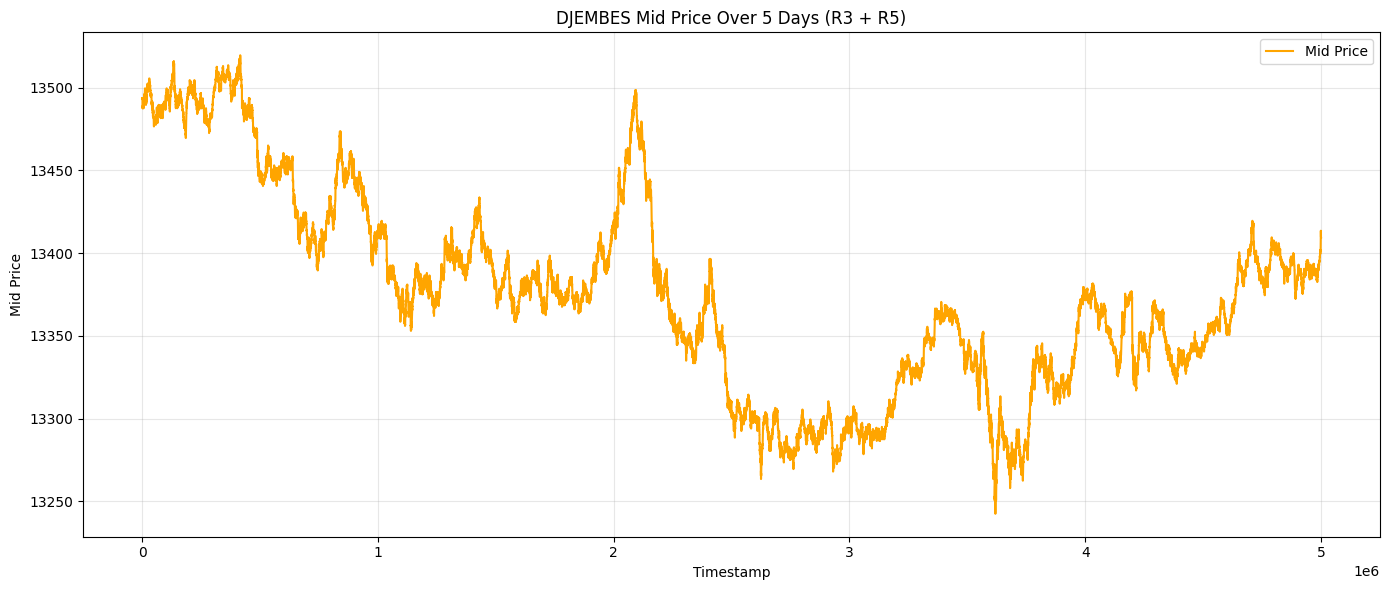

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- File Paths and Offsets ---
file_paths = {
    "R3_Day_0": ("C:/Users/sammy/Desktop/prosperity-main/data/round-3-island-data-bottle/prices_round_3_day_0.csv", 0),
    "R3_Day_1": ("C:/Users/sammy/Desktop/prosperity-main/data/round-3-island-data-bottle/prices_round_3_day_1.csv", 1_000_000),
    "R5_Day_2": ("C:/Users/sammy/Desktop/prosperity-main/rd5/data/prices_round_5_day_2.csv", 2_000_000),
    "R5_Day_3": ("C:/Users/sammy/Desktop/prosperity-main/rd5/data/prices_round_5_day_3.csv", 3_000_000),
    "R5_Day_4": ("C:/Users/sammy/Desktop/prosperity-main/rd5/data/prices_round_5_day_4.csv", 4_000_000),
}

# --- Load and combine DJEMBES data ---
all_djembes = []

for label, (path, offset) in file_paths.items():
    try:
        df = pd.read_csv(path, sep=';')
        df = df[df["product"] == "DJEMBES"].copy()
        df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce") + offset
        df["bid_price_1"] = pd.to_numeric(df["bid_price_1"], errors="coerce")
        df["ask_price_1"] = pd.to_numeric(df["ask_price_1"], errors="coerce")
        df["mid_price"] = (df["bid_price_1"] + df["ask_price_1"]) / 2
        all_djembes.append(df[["timestamp", "mid_price"]])
    except Exception as e:
        print(f"Error loading {label}: {e}")

# --- Combine and sort ---
if all_djembes:
    df_all = pd.concat(all_djembes).sort_values("timestamp")
else:
    print("❌ No data loaded.")
    exit()

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(df_all["timestamp"], df_all["mid_price"], label="Mid Price", color="orange")
plt.title("DJEMBES Mid Price Over 5 Days (R3 + R5)")
plt.xlabel("Timestamp")
plt.ylabel("Mid Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
